In [71]:
import numpy as np
import pandas as pd
import requests
import time
import zipfile
import eurostat

In [72]:
#dane baza danych API BDL lokalne polskie wiec jesli dla innyc krajow to musimy wziac z eurostat 
BASE = "https://bdl.stat.gov.pl/api/v1"
#kod do importowania wzialem z chata ale widze ze zaczytalo wszystko ok ;) jakbys mogl spojrzec
def get_bdl_variable(var_id, years, unit_level=3, name="variable"):
    rows = []

    for year in years:
        params = {
            "year": year,
            "unitLevel": unit_level,
            "page": 0,
            "pageSize": 100,
            "format": "json",
            "lang": "pl"
        }

        url = f"{BASE}/data/by-variable/{var_id}"
        response = requests.get(url, params=params)
        response.raise_for_status()
        data = response.json()

        for item in data.get("results", []):
            unit_id = item.get("id") or item.get("unitId")
            unit_name = item.get("name") or item.get("unitName")

            for value in item.get("values", []):
                rows.append({
                    "unit_id_bdl": unit_id,
                    "region_name": unit_name,
                    "year": int(value.get("year", year)),
                    name: value.get("val")
                })

    

    return pd.DataFrame(rows)

years = range(2008, 2025)

wydatki_900 = get_bdl_variable(
    var_id=152670,
    years=years,
    unit_level=3,
    name="wydatki_dzial_900"
)

oze_prod = get_bdl_variable(
    var_id=194886,
    years=range(2008, 2025),
    unit_level=3,
    name="oze_produkcja"
)

oze_share = get_bdl_variable(
    var_id=288086,
    years=range(2008, 2025),
    unit_level=3,
    name="oze_udzial"
)

energia_ratio = get_bdl_variable(
    var_id=454054,
    years=range(2008, 2025),
    unit_level=3,
    name="produkcja_do_zuzycia_energii"
)


In [73]:
import eurostat
import pandas as pd

def eurostat_to_long(code):
    df = eurostat.get_data_df(code, flags=False)
    time_cols = [c for c in df.columns if str(c).isdigit()]
    id_cols = [c for c in df.columns if c not in time_cols]

    long = df.melt(
        id_vars=id_cols,
        value_vars=time_cols,
        var_name="year",
        value_name="value"
    )

    long["year"] = long["year"].astype(int)
    return long

gdp_raw = eurostat_to_long("nama_10r_2gdp")
unemp_raw = eurostat_to_long("tgs00010")
pop_raw = eurostat_to_long("demo_r_d2jan")


print(gdp_raw.columns)

Index(['freq', 'unit', 'geo\TIME_PERIOD', 'year', 'value'], dtype='str')


In [74]:
def get_geo_col(df):
    for c in df.columns:
        if "geo" in c.lower():
            return c
    raise ValueError("Nie znaleziono kolumny geo")

geo_gdp = get_geo_col(gdp_raw)
geo_unemp = get_geo_col(unemp_raw)
geo_pop = get_geo_col(pop_raw)

gdp_pl = gdp_raw[
    gdp_raw[geo_gdp].astype(str).str.startswith("PL")
].copy()

unemp_pl = unemp_raw[
    unemp_raw[geo_unemp].astype(str).str.startswith("PL")
].copy()

pop_pl = pop_raw[
    pop_raw[geo_pop].astype(str).str.startswith("PL")
].copy()

In [75]:
from functools import reduce

bdl_frames = [wydatki_900, oze_prod, oze_share, energia_ratio]

bdl_panel = reduce(
    lambda left, right: pd.merge(
        left, right,
        on=["unit_id_bdl", "region_name", "year"],
        how="outer"
    ),
    bdl_frames
)

In [76]:
nuts_map = {
    "REGION DOLNOŚLĄSKIE": "PL51",
    "REGION KUJAWSKO-POMORSKIE": "PL61",
    "REGION LUBELSKIE": "PL81",
    "REGION LUBUSKIE": "PL43",
    "REGION ŁÓDZKIE": "PL71",
    "REGION MAŁOPOLSKIE": "PL21",
    "REGION OPOLSKIE": "PL52",
    "REGION PODKARPACKIE": "PL82",
    "REGION PODLASKIE": "PL84",
    "REGION POMORSKIE": "PL63",
    "REGION ŚLĄSKIE": "PL22",
    "REGION ŚWIĘTOKRZYSKIE": "PL72",
    "REGION WARMIŃSKO-MAZURSKIE": "PL62",
    "REGION WIELKOPOLSKIE": "PL41",
    "REGION ZACHODNIOPOMORSKIE": "PL42",
    "REGION WARSZAWSKI STOŁECZNY": "PL91",
    "REGION MAZOWIECKI REGIONALNY": "PL92",
}

bdl_panel["region_clean"] = (
    bdl_panel["region_name"]
    .str.upper()
    .str.replace("  ", " ", regex=False)
    .str.strip()
)

bdl_panel["geo"] = bdl_panel["region_clean"].map(nuts_map)

In [77]:
import pandas as pd
import requests
import zipfile
import io
import re

# teraz idziemy po dane dotyczace emisji CO2 itp z ponizszego linku 

url = "https://jeodpp.jrc.ec.europa.eu/ftp/jrc-opendata/EDGAR/datasets/subnational_NUTS2/2025_FT2024_GHG_NUTS2/EDGAR_2025_GHGs_CO2eq_AR5_NUTS2_by_country_sector_1990-2024_b.zip"

response = requests.get(url)
response.raise_for_status()

z = zipfile.ZipFile(io.BytesIO(response.content))
data_file = z.namelist()[0]

print("Wczytuję:", data_file)

# Czytaj zakladkę "Fossil CO2", header w wierszu 7 (indeks 6)
edgar = pd.read_excel(z.open(data_file), engine="openpyxl", sheet_name="Fossil CO2", header=6)

print("EDGAR shape:", edgar.shape)
print("Kolumny EDGAR:")
print(edgar.columns.tolist())


geo_col = "Subnational code *"

if geo_col not in edgar.columns:
    raise ValueError(f"Nie znaleziono kolumny '{geo_col}'. Dostępne kolumny: {edgar.columns.tolist()}")

print(f"✓ Znaleziono kolumnę geo: {geo_col}")

# bierzemy tylko dla PL w kolumnie GEO COL

edgar_pl = edgar[
    edgar[geo_col].astype(str).str.startswith("PL", na=False)
].copy()

print(f"Liczba wierszy dla Polski: {edgar_pl.shape[0]}")
print(f"Unikalne kody PL: {sorted(edgar_pl[geo_col].unique())}")

# tutaj filtr dalej na dane lata i kolumny

year_cols = []

for col in edgar_pl.columns:
    col_str = str(col).replace("Y_", "").strip()
    if col_str.isdigit():
        year = int(col_str)
        if 1990 <= year <= 2024:
            year_cols.append(col)

if len(year_cols) == 0:
    raise ValueError("Nie znaleziono kolumn z latami 1990-2024.")

print(f"Znalezione lata: {sorted([int(str(c).replace('Y_', '')) for c in year_cols])}")


df_long = edgar_pl.melt(
    id_vars=[geo_col],
    value_vars=year_cols,
    var_name="year",
    value_name="ghg_co2eq"
)

df_long = df_long.rename(columns={geo_col: "geo"})

df_long["geo"] = df_long["geo"].astype(str)
df_long["year"] = (
    df_long["year"]
    .astype(str)
    .str.replace("Y_", "", regex=False)
    .astype(int)
)

df_long["ghg_co2eq"] = pd.to_numeric(df_long["ghg_co2eq"], errors="coerce")

# --- 6. Zakres lat do analizy ---

df_long = df_long[
    (df_long["year"] >= 2008) &
    (df_long["year"] <= 2024)
].copy()

# --- 7. Suma emisji po sektorach dla regionu NUTS2 i roku ---

panel_emisje = (
    df_long
    .groupby(["geo", "year"], as_index=False)["ghg_co2eq"]
    .sum(min_count=1)
)

print("\n✓ panel_emisje gotowe:")
display(panel_emisje.head(10))
print(f"Shape: {panel_emisje.shape}")
print(f"Regiony: {sorted(panel_emisje['geo'].unique())}")

Wczytuję: EDGAR_2025_GHGs_CO2eq_AR5_NUTS2_by_country_sector_1990-2024_b.xlsx
EDGAR shape: (3767, 41)
Kolumny EDGAR:
['Substance', 'ISO', 'Country', 'Subnational code *', 'Subnational desc', 'Sector', 'Y_1990', 'Y_1991', 'Y_1992', 'Y_1993', 'Y_1994', 'Y_1995', 'Y_1996', 'Y_1997', 'Y_1998', 'Y_1999', 'Y_2000', 'Y_2001', 'Y_2002', 'Y_2003', 'Y_2004', 'Y_2005', 'Y_2006', 'Y_2007', 'Y_2008', 'Y_2009', 'Y_2010', 'Y_2011', 'Y_2012', 'Y_2013', 'Y_2014', 'Y_2015', 'Y_2016', 'Y_2017', 'Y_2018', 'Y_2019', 'Y_2020', 'Y_2021', 'Y_2022', 'Y_2023', 'Y_2024']
✓ Znaleziono kolumnę geo: Subnational code *
Liczba wierszy dla Polski: 100
Unikalne kody PL: ['PL21', 'PL22', 'PL41', 'PL42', 'PL43', 'PL51', 'PL52', 'PL61', 'PL62', 'PL63', 'PL71', 'PL72', 'PL81', 'PL82', 'PL84', 'PL91', 'PL92']
Znalezione lata: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 202

,geo,year,ghg_co2eq
0,PL21,2008,20899.961138
1,PL21,2009,19694.553818
2,PL21,2010,20134.047213
3,PL21,2011,19692.594855
4,PL21,2012,19515.283428
5,PL21,2013,19536.724701
6,PL21,2014,18770.922161
7,PL21,2015,18732.648716
8,PL21,2016,18889.460270
9,PL21,2017,19195.606551


Shape: (289, 3)
Regiony: ['PL21', 'PL22', 'PL41', 'PL42', 'PL43', 'PL51', 'PL52', 'PL61', 'PL62', 'PL63', 'PL71', 'PL72', 'PL81', 'PL82', 'PL84', 'PL91', 'PL92']


In [65]:

import pandas as pd
import numpy as np

panel = bdl_panel.merge(panel_emisje, on=["geo", "year"], how="left")

# gdp_pl, unemp_pl, pop_pl
gdp_panel = gdp_pl.rename(columns={geo_gdp: "geo", "value": "gdp"})[
    ["geo", "year", "gdp", "unit"]
]

unemp_panel = unemp_pl.rename(columns={geo_unemp: "geo", "value": "unemployment"})[
    ["geo", "year", "unemployment"]
]

pop_panel = pop_pl.rename(columns={geo_pop: "geo", "value": "population"})[
    ["geo", "year", "population"]
]

panel = (
    panel
    .merge(gdp_panel, on=["geo", "year"], how="left")
    .merge(unemp_panel, on=["geo", "year"], how="left")
    .merge(pop_panel, on=["geo", "year"], how="left")
)

panel.to_csv("panel_zielona_transformacja_nuts2_PL.csv", index=False)

In [66]:
panel["wydatki_900_pc"] = panel["wydatki_dzial_900"] / panel["population"]
panel["log_ghg"] = np.log(panel["ghg_co2eq"])
panel["log_gdp"] = np.log(panel["gdp"])

panel = panel.sort_values(["geo", "year"])
panel["wydatki_900_pc_lag1"] = panel.groupby("geo")["wydatki_900_pc"].shift(1)

In [ ]:

#  agregacja danych oraz zostaw tylko obserwacje z kodem POLSKA :) Polska gurom xD 

panel_model = panel.copy()

panel_model = panel_model[
    panel_model["geo"].astype(str).str.match(r"^PL[0-9]{2}$", na=False)
].copy()

# konwersja zmiennych zeby byly numeryczne 
num_cols = [
    "wydatki_dzial_900",
    "oze_produkcja",
    "oze_udzial",
    "produkcja_do_zuzycia_energii",
    "ghg_co2eq",
    "gdp",
    "unemployment",
    "population",
    "wydatki_900_pc",
    "wydatki_900_pc_lag1"
]

for col in num_cols:
    if col in panel_model.columns:
        panel_model[col] = pd.to_numeric(panel_model[col], errors="coerce")

panel_model["emisje_pc"] = panel_model["ghg_co2eq"] / panel_model["population"]


panel_model["gdp_pc"] = panel_model["gdp"] / panel_model["population"]

# logarytmowanie zmiennych log emicje pc i gdp per capita i wydatki gov 
panel_model["log_emisje_pc"] = np.log(panel_model["emisje_pc"])
panel_model["log_gdp_pc"] = np.log(panel_model["gdp_pc"])
panel_model["log_wydatki_900_pc_lag1"] = np.log1p(panel_model["wydatki_900_pc_lag1"])

# sortowanie i duplikaty checking
panel_model = panel_model.sort_values(["geo", "year"])


duplikaty = panel_model.duplicated(["geo", "year"]).sum()
print("Liczba duplikatów geo-year:", dups)

cols_model = [
    "geo",
    "year",
    "log_emisje_pc",
    "log_wydatki_900_pc_lag1",
    "oze_udzial",
    "produkcja_do_zuzycia_energii",
    "log_gdp_pc",
    "unemployment"
]

print(panel_model[cols_model].isna().sum())

# baza finalnaa
panel_est = panel_model[cols_model].dropna().copy()

print(panel_est.shape)
display(panel_est.head())

Liczba duplikatów geo-year: 895431
geo                                  0
year                                 0
log_emisje_pc                        0
log_wydatki_900_pc_lag1           8697
oze_udzial                           0
produkcja_do_zuzycia_energii         0
log_gdp_pc                           0
unemployment                    410970
dtype: int64
(479808, 8)


,geo,year,log_emisje_pc,log_wydatki_900_pc_lag1,oze_udzial,produkcja_do_zuzycia_energii,log_gdp_pc,unemployment
13338,PL21,2014,-4.510146,0.0,9.5,50.2,-5.180692,19.4
13339,PL21,2014,inf,0.0,9.5,50.2,inf,19.4
13341,PL21,2014,0.172679,0.0,9.5,50.2,-0.497867,19.4
13342,PL21,2014,0.154173,0.0,9.5,50.2,-0.516373,19.4
13343,PL21,2014,0.120500,0.0,9.5,50.2,-0.550046,19.4


In [68]:
### tu modelujemy i robimy tabele opisowa

panel_model = panel.copy()

panel_model["emisje_pc"] = panel_model["ghg_co2eq"] / panel_model["population"]
panel_model["gdp_pc"] = panel_model["gdp"] / panel_model["population"]

panel_model["log_emisje_pc"] = np.log(panel_model["emisje_pc"])
panel_model["log_gdp_pc"] = np.log(panel_model["gdp_pc"])
panel_model["log_wydatki_900_pc_lag1"] = np.log1p(panel_model["wydatki_900_pc_lag1"])

cols_model = [
    "geo",
    "year",
    "log_emisje_pc",
    "log_wydatki_900_pc_lag1",
    "oze_udzial",
    "produkcja_do_zuzycia_energii",
    "log_gdp_pc",
    "unemployment"
]

panel_est = panel_model[cols_model].dropna().copy()

# tabela opisowa
desc = panel_est[
    [
        "log_emisje_pc",
        "log_wydatki_900_pc_lag1",
        "oze_udzial",
        "produkcja_do_zuzycia_energii",
        "log_gdp_pc",
        "unemployment"
    ]
].describe().T

display(desc)

/Users/karolsadoch/Eko_panel_proj/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/karolsadoch/Eko_panel_proj/.venv/lib/python3.14/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
log_emisje_pc,479808.0,inf,NaN,-5.428906,-0.259124,0.194418,0.819910,inf
log_wydatki_900_pc_lag1,479808.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
oze_udzial,479808.0,10.498214,6.426174,3.200000,6.600000,8.400000,14.400000,27.6
produkcja_do_zuzycia_energii,479808.0,70.835268,24.696095,37.200000,46.200000,73.800000,91.300000,106.1
log_gdp_pc,479808.0,inf,NaN,-11.616665,-4.160642,0.182603,1.459599,inf
unemployment,479808.0,5.510268,4.741918,1.600000,2.800000,3.700000,6.625000,29.8


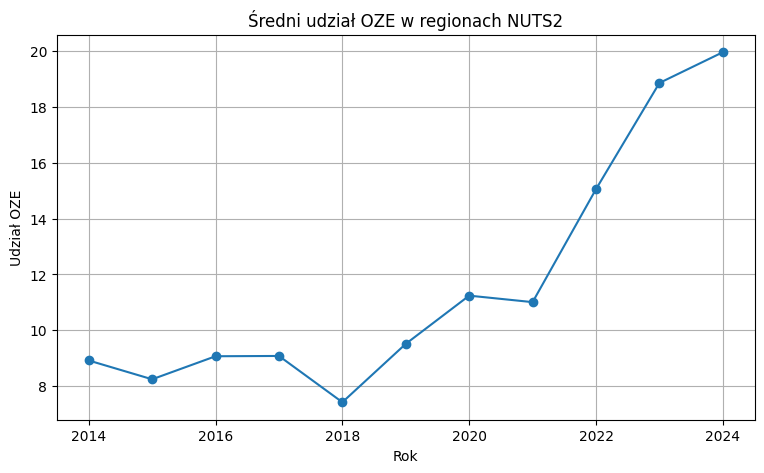

In [69]:
avg_oze = panel_est.groupby("year", as_index=False)["oze_udzial"].mean()

plt.figure(figsize=(9, 5))
plt.plot(avg_oze["year"], avg_oze["oze_udzial"], marker="o")
plt.title("Średni udział OZE w regionach NUTS2")
plt.xlabel("Rok")
plt.ylabel("Udział OZE")
plt.grid(True)
plt.show()

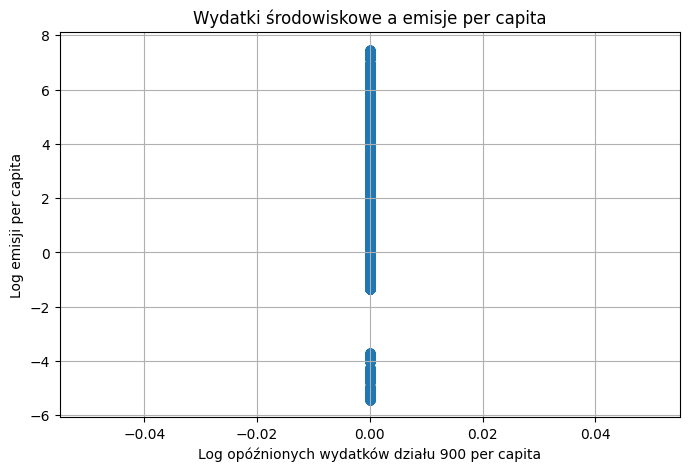

In [70]:
plt.figure(figsize=(8, 5))
plt.scatter(
    panel_est["log_wydatki_900_pc_lag1"],
    panel_est["log_emisje_pc"],
    alpha=0.7
)
plt.title("Wydatki środowiskowe a emisje per capita")
plt.xlabel("Log opóźnionych wydatków działu 900 per capita")
plt.ylabel("Log emisji per capita")
plt.grid(True)
plt.show()

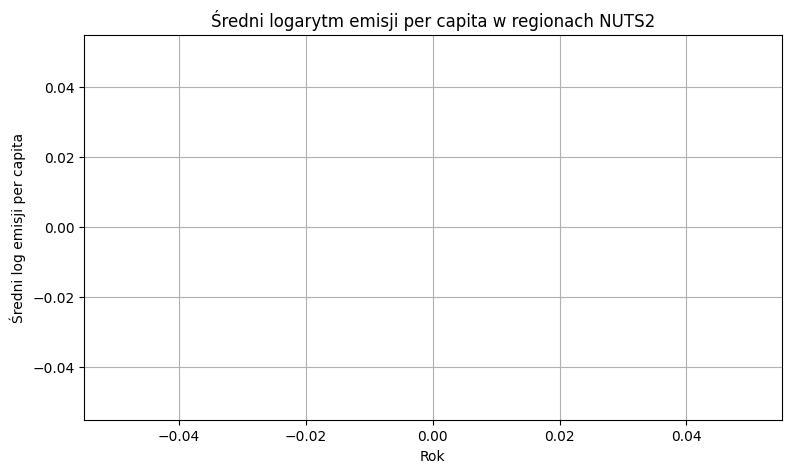

In [ ]:
import matplotlib.pyplot as plt

avg_year = panel_est.groupby("year", as_index=False)["log_emisje_pc"].mean()

plt.figure(figsize=(9, 5))
plt.plot(avg_year["year"], avg_year["log_emisje_pc"], marker="o")
plt.title("Średni logarytm emisji per capita)
plt.xlabel("Rok")
plt.ylabel("Średni log emisji per capita")
plt.grid(True)
plt.show()